# T-GARNet — reinferencia completa por ventana y por sujeto

Ejecuta la celda siguiente. El código carga los 120 sujetos, descubre los 50 checkpoints, reproduce las métricas guardadas, exporta predicciones por ventana, resultados por sujeto, el heatmap y los archivos `.dat` para TikZ.


Device: cpu
MODEL_ROOT: /kaggle/input/datasets/alejandragomezr/models-cte-net/resultados_tgarnet_tdah_ARTCULO-20260715T223758Z-1-001/resultados_tgarnet_tdah_ARTÍCULO
OUTPUT_ROOT: /kaggle/working/TGARNet_reinference_complete
DATOS PROCESADOS
X: (8213, 19, 512) float32
y: (8213,) int64
Sujetos: 120
No utilizado: ['v36p']
CHECKPOINTS DESCUBIERTOS
Total: 50
Seed 0: /kaggle/input/datasets/alejandragomezr/models-cte-net/resultados_tgarnet_tdah_ARTCULO-20260715T223758Z-1-001/resultados_tgarnet_tdah_ARTÍCULO/repeat_seed_0/fixed_best_params_TGARNet_TDAH/fixedparams_tgarnet_seed_0
Seed 1: /kaggle/input/datasets/alejandragomezr/models-cte-net/resultados_tgarnet_tdah_ARTCULO-20260715T223758Z-1-001/resultados_tgarnet_tdah_ARTÍCULO/repeat_seed_1/fixed_best_params_TGARNet_TDAH/fixedparams_tgarnet_seed_1
Seed 2: /kaggle/input/datasets/alejandragomezr/models-cte-net/resultados_tgarnet_tdah_ARTCULO-20260715T223758Z-1-001/resultados_tgarnet_tdah_ARTÍCULO/repeat_seed_2/fixed_best_params_TGARNet_TDAH/fixed

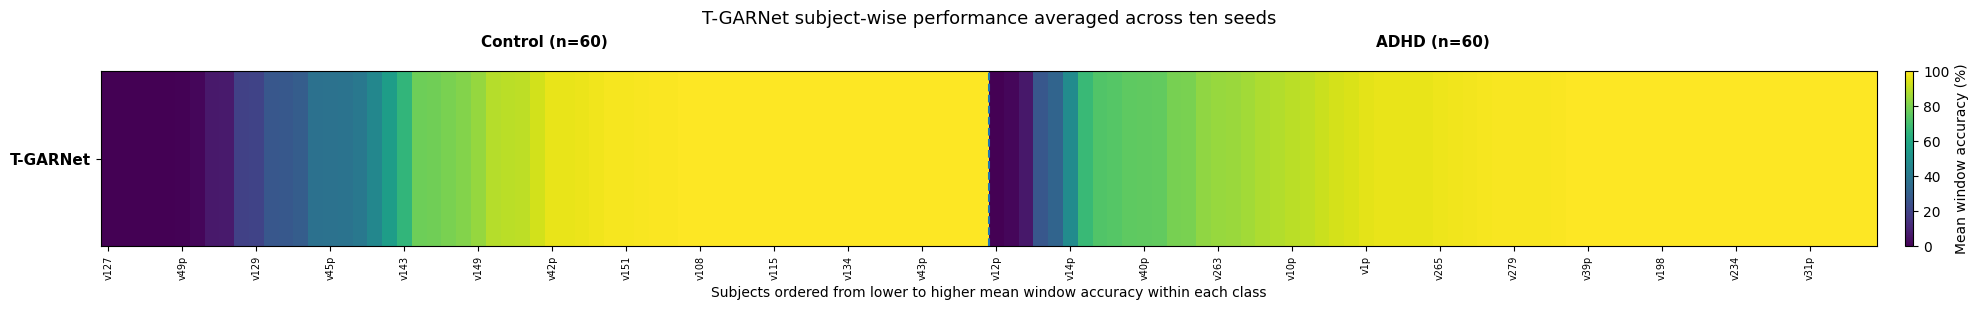


HEATMAP Y ARCHIVOS TIKZ
PNG: /kaggle/working/TGARNet_reinference_complete/figures/TGARNet_heatmap_mean_by_subject.png
PDF: /kaggle/working/TGARNet_reinference_complete/figures/TGARNet_heatmap_mean_by_subject.pdf
DAT principal: /kaggle/working/TGARNet_reinference_complete/figures/tikz_data/TGARNet_heatmap_mean_by_subject.dat
DAT ticks: /kaggle/working/TGARNet_reinference_complete/figures/tikz_data/TGARNet_heatmap_subject_ticks.dat
DAT clases: /kaggle/working/TGARNet_reinference_complete/figures/tikz_data/TGARNet_heatmap_classes.dat
Macros LaTeX: /kaggle/working/TGARNet_reinference_complete/figures/tikz_data/TGARNet_heatmap_axis_settings.tex

PROCESO FINALIZADO
Todos los archivos se guardaron en:
/kaggle/working/TGARNet_reinference_complete

Primeros sujetos del resumen:
  model subject_id  label class_name  fold  n_seeds  n_windows_per_seed  mean_window_accuracy  std_window_accuracy  median_window_accuracy  min_window_accuracy  max_window_accuracy  mean_prob_adhd  mean_window_accuracy_

In [1]:

import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import gc
import json
import math
import pickle
import random
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    precision_score,
    cohen_kappa_score,
    roc_auc_score,
)


# ============================================================
# 1. RUTAS Y CONFIGURACIÓN
# ============================================================

DATA_ROOT = Path(
    "/kaggle/input/datasets/daprosero/mi-tdah-dataset/"
    "MI_TDAH_Dataset/TDAH"
)

FOLDS_PATH = DATA_ROOT / "folds.pkl"
ADHD_DIR = DATA_ROOT / "ieee/ADHD_group"
CONTROL_DIR = DATA_ROOT / "ieee/Control_group"

MODEL_ROOT = Path(
    "/kaggle/input/datasets/alejandragomezr/models-cte-net/"
    "resultados_tgarnet_tdah_ARTCULO-20260715T223758Z-1-001/"
    "resultados_tgarnet_tdah_ARTÍCULO"
)

OUTPUT_ROOT = Path(
    "/kaggle/working/TGARNet_reinference_complete"
)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

FIGURE_DIR = OUTPUT_ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TIKZ_DIR = FIGURE_DIR / "tikz_data"
TIKZ_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

BATCH_SIZE = 16
NUM_WORKERS = 0
N_SEEDS = 10
N_FOLDS = 5
METRIC_TOLERANCE = 1e-6

MODEL_NAME = "TGARNet"

# Hiperparámetros fijos usados en las diez repeticiones del notebook original
MODEL_ARGS = {
    "nb_classes": 2,
    "Chans": 19,
    "Samples": 512,
    "norm_rate": 0.25,
    "alpha": 2,
    "num_heads": 3,
    "intermediate_dim": 16,
    "filters": 2,
    "dropoutRate": 0.3,
    "kernel_sigma": 20.0,
}


# ============================================================
# 2. REPRODUCIBILIDAD
# ============================================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass


# ============================================================
# 3. CARGA Y SEGMENTACIÓN DE LOS 120 SUJETOS
# ============================================================

def clean_subject_id(value):
    if isinstance(value, bytes):
        value = value.decode("utf-8")

    value = Path(str(value)).name

    if value.lower().endswith(".mat"):
        value = value[:-4]

    return value.strip()


def normalize_folds(raw_folds):
    folds = []

    for fold_idx, fold_item in enumerate(raw_folds):
        if isinstance(fold_item, (list, tuple)) and len(fold_item) == 3:
            train_subjects, val_subjects, test_subjects = fold_item

        elif isinstance(fold_item, dict):
            train_subjects = (
                fold_item.get("train")
                or fold_item.get("train_subjects")
                or fold_item.get("subjects_train")
            )
            val_subjects = (
                fold_item.get("val")
                or fold_item.get("validation")
                or fold_item.get("val_subjects")
                or fold_item.get("subjects_val")
            )
            test_subjects = (
                fold_item.get("test")
                or fold_item.get("test_subjects")
                or fold_item.get("subjects_test")
            )

            if (
                train_subjects is None
                or val_subjects is None
                or test_subjects is None
            ):
                raise ValueError(
                    f"No fue posible interpretar el fold {fold_idx}."
                )
        else:
            raise TypeError(
                f"Formato no reconocido para el fold {fold_idx}: "
                f"{type(fold_item)}"
            )

        folds.append(
            (
                [clean_subject_id(x) for x in train_subjects],
                [clean_subject_id(x) for x in val_subjects],
                [clean_subject_id(x) for x in test_subjects],
            )
        )

    return folds


def build_mat_index(directory):
    directory = Path(directory)

    if not directory.exists():
        raise FileNotFoundError(
            f"No existe la carpeta de datos:\n{directory}"
        )

    files = {
        path.stem: path
        for path in sorted(directory.glob("*.mat"))
    }

    if not files:
        raise FileNotFoundError(
            f"No se encontraron archivos .mat en:\n{directory}"
        )

    return files


def load_subject_eeg(mat_path, subject_id, expected_channels=19):
    mat = scipy.io.loadmat(mat_path)

    if subject_id in mat:
        variable_name = subject_id
        raw = np.asarray(mat[subject_id])
    else:
        candidates = []

        for key, value in mat.items():
            if key.startswith("__"):
                continue

            array = np.asarray(value)

            if (
                array.ndim == 2
                and np.issubdtype(array.dtype, np.number)
                and expected_channels in array.shape
            ):
                candidates.append((key, array))

        if not candidates:
            available = {
                key: np.asarray(value).shape
                for key, value in mat.items()
                if not key.startswith("__")
            }
            raise ValueError(
                f"No se encontró una matriz EEG válida en {mat_path}.\n"
                f"Variables disponibles: {available}"
            )

        variable_name, raw = max(
            candidates,
            key=lambda item: item[1].size,
        )

    raw = np.asarray(raw, dtype=np.float32)

    # El código original usaba data[columna].T.
    eeg = raw.T

    # Respaldo para archivos ya almacenados como canales × tiempo.
    if eeg.shape[0] != expected_channels and raw.shape[0] == expected_channels:
        eeg = raw

    if eeg.ndim != 2 or eeg.shape[0] != expected_channels:
        raise ValueError(
            f"Forma inesperada para {subject_id}: {eeg.shape}. "
            f"Se esperaba ({expected_channels}, tiempo)."
        )

    if not np.isfinite(eeg).all():
        raise ValueError(
            f"La señal de {subject_id} contiene NaN o Inf."
        )

    return eeg.astype(np.float32), variable_name


def process_adhd_subjects(
    folds_path=FOLDS_PATH,
    adhd_dir=ADHD_DIR,
    control_dir=CONTROL_DIR,
    window_size=512,
    overlap=0.50,
):
    with open(folds_path, "rb") as file:
        raw_folds = pickle.load(file)

    folds = normalize_folds(raw_folds)

    if len(folds) != N_FOLDS:
        raise ValueError(
            f"Se esperaban {N_FOLDS} folds y se encontraron {len(folds)}."
        )

    protocol_subjects = set()
    test_counter = Counter()

    for fold_idx, (train, val, test) in enumerate(folds):
        train_set = set(train)
        val_set = set(val)
        test_set = set(test)

        if train_set & val_set:
            raise ValueError(
                f"Hay solapamiento train-val en el fold {fold_idx}."
            )
        if train_set & test_set:
            raise ValueError(
                f"Hay solapamiento train-test en el fold {fold_idx}."
            )
        if val_set & test_set:
            raise ValueError(
                f"Hay solapamiento val-test en el fold {fold_idx}."
            )

        protocol_subjects.update(
            train_set | val_set | test_set
        )
        test_counter.update(test)

    if len(protocol_subjects) != 120:
        raise ValueError(
            f"Se esperaban 120 sujetos en folds.pkl y se encontraron "
            f"{len(protocol_subjects)}."
        )

    invalid_test_counts = {
        subject: count
        for subject, count in test_counter.items()
        if count != 1
    }

    if invalid_test_counts:
        raise ValueError(
            "Cada sujeto debe aparecer exactamente una vez en test. "
            f"Problemas: {invalid_test_counts}"
        )

    adhd_files = build_mat_index(adhd_dir)
    control_files = build_mat_index(control_dir)

    duplicated = set(adhd_files) & set(control_files)

    if duplicated:
        raise ValueError(
            f"Identificadores presentes en ambas clases: {sorted(duplicated)}"
        )

    available_subjects = set(adhd_files) | set(control_files)
    missing_subjects = protocol_subjects - available_subjects

    if missing_subjects:
        raise FileNotFoundError(
            f"Faltan archivos para estos sujetos: {sorted(missing_subjects)}"
        )

    control_subjects = sorted(
        protocol_subjects & set(control_files)
    )
    adhd_subjects = sorted(
        protocol_subjects & set(adhd_files)
    )

    if len(control_subjects) != 60 or len(adhd_subjects) != 60:
        raise ValueError(
            "La cohorte de folds.pkl no está balanceada: "
            f"Control={len(control_subjects)}, ADHD={len(adhd_subjects)}."
        )

    unused_subjects = sorted(
        available_subjects - protocol_subjects
    )

    # Mantener el orden original: controles primero y luego TDAH.
    subject_records = (
        [
            (subject, 0, "Control", control_files[subject])
            for subject in control_subjects
        ]
        +
        [
            (subject, 1, "ADHD", adhd_files[subject])
            for subject in adhd_subjects
        ]
    )

    stride = int(round(window_size * (1.0 - overlap)))

    if stride <= 0:
        raise ValueError(
            "El stride debe ser mayor que cero."
        )

    X = []
    y = []
    subject_ids = []
    window_ids = []
    rows = []

    global_window_index = 0

    for subject_position, (
        subject_id,
        label,
        class_name,
        mat_path,
    ) in enumerate(subject_records):

        eeg, variable_name = load_subject_eeg(
            mat_path=mat_path,
            subject_id=subject_id,
            expected_channels=19,
        )

        n_samples = eeg.shape[1]

        if n_samples < window_size:
            raise ValueError(
                f"{subject_id} tiene solo {n_samples} muestras."
            )

        local_window_id = 0

        for start_sample in range(
            0,
            n_samples - window_size + 1,
            stride,
        ):
            end_sample = start_sample + window_size

            X.append(
                eeg[:, start_sample:end_sample]
            )
            y.append(label)
            subject_ids.append(subject_id)
            window_ids.append(local_window_id)

            rows.append(
                {
                    "global_window_index": global_window_index,
                    "subject_position": subject_position,
                    "subject_id": subject_id,
                    "label": label,
                    "class_name": class_name,
                    "window_id": local_window_id,
                    "window_name": f"Window {local_window_id + 1}",
                    "start_sample": start_sample,
                    "end_sample": end_sample,
                    "n_recording_samples": n_samples,
                    "mat_variable": variable_name,
                    "mat_filename": mat_path.name,
                }
            )

            local_window_id += 1
            global_window_index += 1

    X = np.stack(X).astype(np.float32)
    y_int = np.asarray(y, dtype=np.int64)
    subject_ids = np.asarray(subject_ids, dtype=str)
    window_ids = np.asarray(window_ids, dtype=np.int64)
    metadata = pd.DataFrame(rows)

    if X.shape[1:] != (19, 512):
        raise ValueError(
            f"Forma final inesperada para X: {X.shape}"
        )

    if len(np.unique(subject_ids)) != 120:
        raise ValueError(
            "No se procesaron exactamente 120 sujetos."
        )

    print("=" * 80)
    print("DATOS PROCESADOS")
    print("=" * 80)
    print("X:", X.shape, X.dtype)
    print("y:", y_int.shape, y_int.dtype)
    print("Sujetos:", len(np.unique(subject_ids)))
    print("No utilizado:", unused_subjects)

    return {
        "X": X,
        "y_int": y_int,
        "y_onehot": np.eye(2, dtype=np.float32)[y_int],
        "subject_ids": subject_ids,
        "window_ids": window_ids,
        "metadata": metadata,
        "folds": folds,
        "unused_subjects": unused_subjects,
    }


# ============================================================
# 4. ARQUITECTURA T-GARNET
# ============================================================

class GaussianKernelLayer(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x, sigma):
        if not torch.is_tensor(sigma):
            sigma = torch.tensor(
                sigma,
                dtype=x.dtype,
                device=x.device,
            )
        else:
            sigma = sigma.to(
                dtype=x.dtype,
                device=x.device,
            )

        batch_size, n_channels, n_samples, n_filters = x.shape

        x = x.permute(0, 3, 1, 2)
        x_reshaped = x.reshape(
            batch_size * n_filters,
            n_channels,
            n_samples,
        )

        differences = (
            x_reshaped.unsqueeze(2)
            - x_reshaped.unsqueeze(1)
        )

        pairwise_distances_squared = (
            differences.pow(2).sum(dim=-1)
        )

        pairwise_distances_squared = (
            pairwise_distances_squared
            .reshape(
                batch_size,
                n_filters,
                n_channels,
                n_channels,
            )
            .permute(0, 2, 3, 1)
        )

        return torch.exp(
            -pairwise_distances_squared
            / (2.0 * sigma.pow(2))
        )


class RenyiEntropyLayer(nn.Module):
    def __init__(
        self,
        alpha=2,
        eps=1e-8,
        normalize_by_logc=False,
    ):
        super().__init__()
        self.alpha = alpha
        self.eps = eps
        self.normalize_by_logc = normalize_by_logc

    def forward(self, kernel_matrix):
        kernel_matrix = kernel_matrix.float()

        trace = (
            torch.diagonal(
                kernel_matrix,
                dim1=-2,
                dim2=-1,
            )
            .sum(dim=-1)
        )

        trace = torch.clamp(
            trace,
            min=self.eps,
        )

        normalized_matrix = (
            kernel_matrix
            / trace.unsqueeze(-1).unsqueeze(-1)
        )

        if self.alpha == 2:
            matrix_product = (
                normalized_matrix
                @ normalized_matrix.transpose(-1, -2)
            )

            trace_product = (
                torch.diagonal(
                    matrix_product,
                    dim1=-2,
                    dim2=-1,
                )
                .sum(dim=-1)
            )

            entropy = -torch.log(
                torch.clamp(
                    trace_product,
                    min=self.eps,
                )
            )
        else:
            eigenvalues = torch.linalg.eigvalsh(
                normalized_matrix
            )

            eigenvalues = torch.clamp(
                eigenvalues.real,
                min=self.eps,
            )

            entropy = (
                torch.log(
                    torch.sum(
                        eigenvalues.pow(self.alpha),
                        dim=-1,
                    )
                )
                / (1.0 - self.alpha)
            )

        if self.normalize_by_logc:
            n_channels = kernel_matrix.shape[-1]
            denominator = torch.log(
                torch.tensor(
                    max(n_channels, 2.0),
                    dtype=entropy.dtype,
                    device=entropy.device,
                )
            )
            entropy = entropy / denominator

        return entropy


class InspectableMultiHeadAttention(nn.Module):
    def __init__(
        self,
        embed_dim,
        num_heads,
        dropout=0.0,
        bias=True,
    ):
        super().__init__()

        if num_heads < 1:
            raise ValueError(
                "num_heads debe ser mayor o igual que 1."
            )

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.key_dim = max(
            1,
            embed_dim // num_heads,
        )
        self.value_dim = self.key_dim
        self.inner_dim = (
            self.num_heads * self.key_dim
        )
        self.scale = math.sqrt(self.key_dim)

        self.q_proj = nn.Linear(
            embed_dim,
            self.inner_dim,
            bias=bias,
        )
        self.k_proj = nn.Linear(
            embed_dim,
            self.inner_dim,
            bias=bias,
        )
        self.v_proj = nn.Linear(
            embed_dim,
            self.inner_dim,
            bias=bias,
        )
        self.out_proj = nn.Linear(
            self.inner_dim,
            embed_dim,
            bias=bias,
        )

        self.dropout = nn.Dropout(dropout)
        self._last_attention_scores = None

    def forward(
        self,
        query,
        key=None,
        value=None,
        attention_mask=None,
    ):
        if key is None:
            key = query

        if value is None:
            value = query

        batch_size, query_length, _ = query.shape
        key_length = key.shape[1]

        q = (
            self.q_proj(query)
            .view(
                batch_size,
                query_length,
                self.num_heads,
                self.key_dim,
            )
            .transpose(1, 2)
        )

        k = (
            self.k_proj(key)
            .view(
                batch_size,
                key_length,
                self.num_heads,
                self.key_dim,
            )
            .transpose(1, 2)
        )

        v = (
            self.v_proj(value)
            .view(
                batch_size,
                key_length,
                self.num_heads,
                self.value_dim,
            )
            .transpose(1, 2)
        )

        scores = (
            torch.matmul(
                q,
                k.transpose(-1, -2),
            )
            / self.scale
        )

        if attention_mask is not None:
            if attention_mask.dtype != torch.bool:
                attention_mask = attention_mask.bool()

            scores = scores.masked_fill(
                ~attention_mask,
                float("-inf"),
            )

        attention_scores = torch.softmax(
            scores,
            dim=-1,
        )

        attention_scores = self.dropout(
            attention_scores
        )

        output = torch.matmul(
            attention_scores,
            v,
        )

        output = (
            output
            .transpose(1, 2)
            .contiguous()
            .view(
                batch_size,
                query_length,
                self.inner_dim,
            )
        )

        output = self.out_proj(output)

        self._last_attention_scores = attention_scores

        return output, attention_scores


class InspectableTransformerEncoder(nn.Module):
    def __init__(
        self,
        embed_dim,
        num_heads,
        intermediate_dim,
        dropout=0.0,
        ff_activation=F.relu,
    ):
        super().__init__()

        self.self_attention = (
            InspectableMultiHeadAttention(
                embed_dim=embed_dim,
                num_heads=num_heads,
                dropout=dropout,
            )
        )

        self.self_attention_layer_norm = (
            nn.LayerNorm(
                embed_dim,
                eps=1e-6,
            )
        )

        self.self_attention_dropout = (
            nn.Dropout(dropout)
        )

        self.feedforward_intermediate_dense = (
            nn.Linear(
                embed_dim,
                intermediate_dim,
            )
        )

        self.feedforward_output_dense = (
            nn.Linear(
                intermediate_dim,
                embed_dim,
            )
        )

        self.feedforward_dropout = (
            nn.Dropout(dropout)
        )

        self.feedforward_layer_norm = (
            nn.LayerNorm(
                embed_dim,
                eps=1e-6,
            )
        )

        self.ff_activation = ff_activation
        self._last_attention_scores = None

    def forward(
        self,
        inputs,
        padding_mask=None,
    ):
        (
            attention_output,
            attention_scores,
        ) = self.self_attention(
            query=inputs,
            key=inputs,
            value=inputs,
            attention_mask=padding_mask,
        )

        self._last_attention_scores = attention_scores

        attention_output = (
            self.self_attention_dropout(
                attention_output
            )
        )

        attention_output = (
            self.self_attention_layer_norm(
                inputs + attention_output
            )
        )

        feedforward_output = (
            self.feedforward_intermediate_dense(
                attention_output
            )
        )

        feedforward_output = self.ff_activation(
            feedforward_output
        )

        feedforward_output = (
            self.feedforward_output_dense(
                feedforward_output
            )
        )

        feedforward_output = (
            self.feedforward_dropout(
                feedforward_output
            )
        )

        return self.feedforward_layer_norm(
            attention_output
            + feedforward_output
        )


class TGARNet(nn.Module):
    def __init__(
        self,
        nb_classes=2,
        Chans=19,
        Samples=512,
        norm_rate=0.25,
        alpha=2,
        num_heads=3,
        intermediate_dim=128,
        filters=3,
        dropoutRate=0.3,
        kernel_sigma=1.0,
        ff_activation=F.relu,
        outer_ln_eps=1e-3,
        bn_eps=1e-3,
        bn_momentum=0.01,
        return_logits=False,
    ):
        super().__init__()

        self.nb_classes = nb_classes
        self.Chans = Chans
        self.Samples = Samples
        self.norm_rate = norm_rate
        self.alpha = alpha
        self.num_heads = num_heads
        self.intermediate_dim = intermediate_dim
        self.filters = filters
        self.dropoutRate = dropoutRate
        self.kernel_sigma = kernel_sigma
        self.return_logits = return_logits

        self.pre_ln = nn.LayerNorm(
            Chans,
            eps=outer_ln_eps,
        )

        self.transformer_encoder = (
            InspectableTransformerEncoder(
                embed_dim=Chans,
                num_heads=num_heads,
                intermediate_dim=intermediate_dim,
                dropout=dropoutRate,
                ff_activation=ff_activation,
            )
        )

        self.post_ln = nn.LayerNorm(
            Chans,
            eps=outer_ln_eps,
        )

        self.gaussian_layer = (
            GaussianKernelLayer()
        )

        self.renyi_entropy = (
            RenyiEntropyLayer(
                alpha=alpha,
                normalize_by_logc=True,
            )
        )

        self.conv1 = nn.Conv2d(
            1,
            filters,
            kernel_size=3,
            padding=1,
        )

        self.bn1 = nn.BatchNorm2d(
            filters,
            eps=bn_eps,
            momentum=bn_momentum,
        )

        self.conv2 = nn.Conv2d(
            filters,
            filters,
            kernel_size=3,
            padding=1,
        )

        self.bn2 = nn.BatchNorm2d(
            filters,
            eps=bn_eps,
            momentum=bn_momentum,
        )

        self.dropout = nn.Dropout(
            dropoutRate
        )

        self.classifier = nn.Linear(
            filters * Chans * Chans,
            nb_classes,
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.pre_ln(x)
        x = self.transformer_encoder(x)
        x = self.post_ln(x)

        x = (
            x.permute(0, 2, 1)
            .unsqueeze(-1)
        )

        kernel_output = self.gaussian_layer(
            x,
            self.kernel_sigma,
        )

        kernel_output_transposed = (
            kernel_output.permute(0, 3, 1, 2)
        )

        kernel_entropy = self.renyi_entropy(
            kernel_output_transposed
        )

        convolution_output = F.selu(
            self.conv1(
                kernel_output_transposed
            )
        )

        convolution_output = self.bn1(
            convolution_output
        )

        convolution_output = F.selu(
            self.conv2(
                convolution_output
            )
        )

        convolution_output = self.bn2(
            convolution_output
        )

        flattened = torch.flatten(
            convolution_output,
            start_dim=1,
        )

        dropped = self.dropout(flattened)

        logits = self.classifier(dropped)
        probabilities = torch.softmax(
            logits,
            dim=1,
        )

        output = {
            "out_activation": probabilities,
            "kernel_entropy": kernel_entropy,
        }

        if self.return_logits:
            output["logits"] = logits

        return output


# ============================================================
# 5. CARGA DE PESOS Y DESCUBRIMIENTO DE LOS 50 FOLDS
# ============================================================

def load_state_dict_file(path):
    try:
        loaded = torch.load(
            path,
            map_location="cpu",
            weights_only=True,
        )
    except TypeError:
        loaded = torch.load(
            path,
            map_location="cpu",
        )
    except Exception:
        loaded = torch.load(
            path,
            map_location="cpu",
            weights_only=False,
        )

    if not isinstance(loaded, dict):
        raise TypeError(
            f"El checkpoint no contiene un diccionario: {path}"
        )

    if "model_state_dict" in loaded:
        state_dict = loaded["model_state_dict"]
    elif "state_dict" in loaded:
        state_dict = loaded["state_dict"]
    else:
        state_dict = loaded

    cleaned = {}

    for key, value in state_dict.items():
        clean_key = key

        for prefix in ("module.", "_orig_mod."):
            if clean_key.startswith(prefix):
                clean_key = clean_key[len(prefix):]

        cleaned[clean_key] = value

    return cleaned


def extract_seed_from_path(path):
    path_string = str(path)

    patterns = [
        r"repeat_seed_(\d+)",
        r"fixedparams_tgarnet_seed_(\d+)",
        r"TGARNet_TDAH_fixed_seed_(\d+)",
        r"fixed_seed_(\d+)",
        r"seed[_-](\d+)",
    ]

    for pattern in patterns:
        match = re.search(
            pattern,
            path_string,
            flags=re.IGNORECASE,
        )
        if match:
            return int(match.group(1))

    return None


def extract_fold_from_path(path):
    matches = re.findall(
        r"fold_(\d+)",
        str(path),
        flags=re.IGNORECASE,
    )

    if not matches:
        return None

    return int(matches[-1])


def checkpoint_priority(path):
    path_string = str(path).lower()

    score = 0

    if "fixedparams_tgarnet_seed_" in path_string:
        score += 100
    if "fixed_best_params_tgarnet_tdah" in path_string:
        score += 50
    if "repeat_seed_" in path_string:
        score += 20
    if (path.parent / "fold_result.pkl").exists():
        score += 10

    # Si hay duplicados, favorecer la ruta más específica y luego la más corta.
    return (
        score,
        -len(path.parts),
    )


def discover_fold_directories(model_root):
    if not model_root.exists():
        raise FileNotFoundError(
            f"No existe la carpeta de modelos:\n{model_root}"
        )

    candidates = {}

    for checkpoint_path in model_root.rglob(
        "best_state.pt"
    ):
        seed = extract_seed_from_path(
            checkpoint_path
        )
        fold = extract_fold_from_path(
            checkpoint_path
        )

        if seed is None or fold is None:
            continue

        if not (0 <= seed < N_SEEDS):
            continue

        if not (0 <= fold < N_FOLDS):
            continue

        key = (seed, fold)

        candidates.setdefault(
            key,
            [],
        ).append(
            checkpoint_path.parent
        )

    mapping = {}

    for key, fold_directories in candidates.items():
        selected = max(
            fold_directories,
            key=lambda directory: checkpoint_priority(
                directory / "best_state.pt"
            ),
        )

        mapping[key] = selected

    expected_keys = {
        (seed, fold)
        for seed in range(N_SEEDS)
        for fold in range(N_FOLDS)
    }

    missing_keys = sorted(
        expected_keys - set(mapping)
    )

    if missing_keys:
        discovered_paths = "\n".join(
            str(path)
            for path in model_root.rglob(
                "best_state.pt"
            )
        )

        raise FileNotFoundError(
            "No se encontraron los 50 checkpoints esperados.\n"
            f"Combinaciones faltantes: {missing_keys}\n\n"
            "Checkpoints descubiertos:\n"
            f"{discovered_paths}"
        )

    print("=" * 80)
    print("CHECKPOINTS DESCUBIERTOS")
    print("=" * 80)
    print(f"Total: {len(mapping)}")

    for seed in range(N_SEEDS):
        fold_paths = [
            mapping[(seed, fold)]
            for fold in range(N_FOLDS)
        ]

        common_parent = Path(
            os.path.commonpath(
                [str(path) for path in fold_paths]
            )
        )

        print(
            f"Seed {seed}: {common_parent}"
        )

    return mapping


# ============================================================
# 6. INFERENCIA Y MÉTRICAS
# ============================================================

def get_test_partition(data, fold_idx):
    test_subjects = data["folds"][fold_idx][2]

    mask = np.isin(
        data["subject_ids"],
        np.asarray(test_subjects, dtype=str),
    )

    test_data = {
        "X": data["X"][mask],
        "y": data["y_int"][mask],
        "subject_ids": data["subject_ids"][mask],
        "window_ids": data["window_ids"][mask],
        "metadata": (
            data["metadata"]
            .loc[mask]
            .reset_index(drop=True)
            .copy()
        ),
        "test_subjects": test_subjects,
    }

    if (
        len(np.unique(test_data["subject_ids"]))
        != 24
    ):
        raise ValueError(
            f"Fold {fold_idx}: se esperaban 24 sujetos de test."
        )

    return test_data


def infer_tgarnet(
    model,
    X,
    batch_size=BATCH_SIZE,
):
    dataset = TensorDataset(
        torch.from_numpy(
            np.asarray(X, dtype=np.float32)
        )
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    all_probabilities = []
    model.eval()

    with torch.inference_mode():
        for (batch_x,) in loader:
            batch_x = batch_x.to(
                device=DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )

            output = model(batch_x)
            probabilities = output[
                "out_activation"
            ]

            all_probabilities.append(
                probabilities
                .detach()
                .cpu()
                .numpy()
            )

    probabilities = np.concatenate(
        all_probabilities,
        axis=0,
    ).astype(np.float32)

    probability_adhd = probabilities[:, 1]
    predictions = np.argmax(
        probabilities,
        axis=1,
    ).astype(np.int64)

    return (
        probabilities,
        probability_adhd,
        predictions,
    )


def calculate_metrics(
    y_true,
    y_pred,
    y_prob,
):
    y_true = np.asarray(
        y_true,
        dtype=np.int64,
    )
    y_pred = np.asarray(
        y_pred,
        dtype=np.int64,
    )
    y_prob = np.asarray(
        y_prob,
        dtype=np.float64,
    )

    try:
        auc_value = roc_auc_score(
            y_true,
            y_prob,
        )
    except ValueError:
        auc_value = np.nan

    return {
        "accuracy": float(
            accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "recall": float(
            recall_score(
                y_true,
                y_pred,
                average="binary",
                zero_division=0,
            )
        ),
        "precision": float(
            precision_score(
                y_true,
                y_pred,
                average="binary",
                zero_division=0,
            )
        ),
        "kappa": float(
            cohen_kappa_score(
                y_true,
                y_pred,
            )
        ),
        "auc": float(auc_value),
    }


def load_saved_fold_result(
    fold_directory,
):
    result_path = (
        fold_directory
        / "fold_result.pkl"
    )

    if not result_path.exists():
        raise FileNotFoundError(
            f"No se encontró:\n{result_path}"
        )

    with open(result_path, "rb") as file:
        result = pickle.load(file)

    if "fold_metrics" not in result:
        raise KeyError(
            f"{result_path} no contiene 'fold_metrics'."
        )

    return result


def summarize_values(values):
    values = np.asarray(
        values,
        dtype=float,
    )

    return {
        "mean": float(
            np.nanmean(values)
        ),
        "std_population": float(
            np.nanstd(
                values,
                ddof=0,
            )
        ),
        "std_sample": float(
            np.nanstd(
                values,
                ddof=1,
            )
        ) if len(values) > 1 else 0.0,
        "n": int(len(values)),
    }


# ============================================================
# 7. RECORRER 10 SEEDS × 5 FOLDS
# ============================================================

def run_all_reinference(data):
    fold_directories = discover_fold_directories(
        MODEL_ROOT
    )

    window_frames = []
    subject_frames = []
    fold_metric_rows = []
    comparison_rows = []

    test_cache = {
        fold: get_test_partition(
            data,
            fold,
        )
        for fold in range(N_FOLDS)
    }

    for seed in range(N_SEEDS):
        for fold in range(N_FOLDS):
            fold_directory = (
                fold_directories[(seed, fold)]
            )

            saved_result = (
                load_saved_fold_result(
                    fold_directory
                )
            )

            saved_metrics = saved_result[
                "fold_metrics"
            ]

            set_seed(seed + fold)

            model = TGARNet(
                **MODEL_ARGS
            ).to(DEVICE)

            state_dict = load_state_dict_file(
                fold_directory
                / "best_state.pt"
            )

            model.load_state_dict(
                state_dict,
                strict=True,
            )

            test = test_cache[fold]

            (
                probabilities,
                probability_adhd,
                predictions,
            ) = infer_tgarnet(
                model=model,
                X=test["X"],
                batch_size=BATCH_SIZE,
            )

            current_metrics = calculate_metrics(
                y_true=test["y"],
                y_pred=predictions,
                y_prob=probability_adhd,
            )

            saved_accuracy = float(
                saved_metrics["accuracy"]
            )
            recomputed_accuracy = float(
                current_metrics["accuracy"]
            )

            print(
                f"seed={seed} fold={fold} | "
                f"guardado={saved_accuracy:.10f} | "
                f"recalculado={recomputed_accuracy:.10f}"
            )

            comparison_row = {
                "model": MODEL_NAME,
                "seed": seed,
                "fold": fold,
                "fold_directory": str(
                    fold_directory
                ),
            }

            metric_matches = []

            # T-GARNet guardó estas cinco métricas en fold_result.pkl.
            for metric in [
                "accuracy",
                "recall",
                "precision",
                "kappa",
                "auc",
            ]:
                saved_value = float(
                    saved_metrics[metric]
                )
                recomputed_value = float(
                    current_metrics[metric]
                )

                matches = bool(
                    np.isclose(
                        saved_value,
                        recomputed_value,
                        atol=METRIC_TOLERANCE,
                        rtol=0.0,
                        equal_nan=True,
                    )
                )

                comparison_row[
                    f"saved_{metric}"
                ] = saved_value

                comparison_row[
                    f"recomputed_{metric}"
                ] = recomputed_value

                comparison_row[
                    f"difference_{metric}"
                ] = (
                    recomputed_value
                    - saved_value
                )

                comparison_row[
                    f"match_{metric}"
                ] = matches

                metric_matches.append(matches)

            comparison_row[
                "all_saved_metrics_match"
            ] = bool(
                all(metric_matches)
            )

            comparison_rows.append(
                comparison_row
            )

            metadata = test["metadata"]

            window_frame = pd.DataFrame(
                {
                    "model": MODEL_NAME,
                    "seed": seed,
                    "fold": fold,
                    "global_window_index": metadata[
                        "global_window_index"
                    ].to_numpy(),
                    "subject_id": test[
                        "subject_ids"
                    ],
                    "label": test["y"],
                    "class_name": np.where(
                        test["y"] == 1,
                        "ADHD",
                        "Control",
                    ),
                    "window_id": test[
                        "window_ids"
                    ],
                    "window_name": metadata[
                        "window_name"
                    ].to_numpy(),
                    "start_sample": metadata[
                        "start_sample"
                    ].to_numpy(),
                    "end_sample": metadata[
                        "end_sample"
                    ].to_numpy(),
                    "y_true": test["y"],
                    "prob_control": probabilities[
                        :, 0
                    ],
                    "prob_adhd": probabilities[
                        :, 1
                    ],
                    "y_pred": predictions,
                    "correct": (
                        predictions == test["y"]
                    ).astype(np.int64),
                }
            )

            window_frames.append(
                window_frame
            )

            subject_frame = (
                window_frame
                .groupby(
                    [
                        "model",
                        "seed",
                        "fold",
                        "subject_id",
                        "label",
                        "class_name",
                    ],
                    as_index=False,
                )
                .agg(
                    n_windows=(
                        "correct",
                        "size",
                    ),
                    n_correct_windows=(
                        "correct",
                        "sum",
                    ),
                    window_accuracy=(
                        "correct",
                        "mean",
                    ),
                    mean_prob_adhd=(
                        "prob_adhd",
                        "mean",
                    ),
                    std_prob_adhd=(
                        "prob_adhd",
                        "std",
                    ),
                )
            )

            subject_frames.append(
                subject_frame
            )

            fold_metric_rows.append(
                {
                    "model": MODEL_NAME,
                    "seed": seed,
                    "fold": fold,
                    "n_test_windows": len(
                        test["y"]
                    ),
                    "n_test_subjects": 24,
                    **current_metrics,
                }
            )

            del (
                model,
                state_dict,
                probabilities,
                probability_adhd,
                predictions,
                window_frame,
                subject_frame,
            )

            gc.collect()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    window_predictions = pd.concat(
        window_frames,
        ignore_index=True,
    )

    subject_by_seed = pd.concat(
        subject_frames,
        ignore_index=True,
    )

    fold_metrics = pd.DataFrame(
        fold_metric_rows
    )

    comparisons = pd.DataFrame(
        comparison_rows
    )

    subject_accuracy = (
        subject_by_seed
        .groupby(
            [
                "model",
                "subject_id",
                "label",
                "class_name",
            ],
            as_index=False,
        )
        .agg(
            fold=("fold", "first"),
            n_seeds=("seed", "nunique"),
            n_windows_per_seed=(
                "n_windows",
                "first",
            ),
            mean_window_accuracy=(
                "window_accuracy",
                "mean",
            ),
            std_window_accuracy=(
                "window_accuracy",
                "std",
            ),
            median_window_accuracy=(
                "window_accuracy",
                "median",
            ),
            min_window_accuracy=(
                "window_accuracy",
                "min",
            ),
            max_window_accuracy=(
                "window_accuracy",
                "max",
            ),
            mean_prob_adhd=(
                "mean_prob_adhd",
                "mean",
            ),
        )
    )

    subject_accuracy[
        "mean_window_accuracy_percent"
    ] = (
        100.0
        * subject_accuracy[
            "mean_window_accuracy"
        ]
    )

    subject_accuracy[
        "std_window_accuracy_percent"
    ] = (
        100.0
        * subject_accuracy[
            "std_window_accuracy"
        ]
    )

    summary_50_rows = []

    metric_names = [
        "accuracy",
        "balanced_accuracy",
        "recall",
        "precision",
        "kappa",
        "auc",
    ]

    for metric in metric_names:
        stats = summarize_values(
            fold_metrics[
                metric
            ].to_numpy(dtype=float)
        )

        summary_50_rows.append(
            {
                "aggregation": "50 folds",
                "metric": metric,
                **stats,
            }
        )

    summary_50 = pd.DataFrame(
        summary_50_rows
    )

    seed_metrics = (
        fold_metrics
        .groupby(
            ["model", "seed"],
            as_index=False,
        )[metric_names]
        .mean()
    )

    summary_10_rows = []

    for metric in metric_names:
        stats = summarize_values(
            seed_metrics[
                metric
            ].to_numpy(dtype=float)
        )

        summary_10_rows.append(
            {
                "aggregation": (
                    "10 seed means "
                    "(mean of 5 folds per seed)"
                ),
                "metric": metric,
                **stats,
            }
        )

    summary_10 = pd.DataFrame(
        summary_10_rows
    )

    if len(fold_metrics) != 50:
        raise RuntimeError(
            f"Se esperaban 50 resultados y se obtuvieron "
            f"{len(fold_metrics)}."
        )

    if len(subject_by_seed) != 1200:
        raise RuntimeError(
            f"Se esperaban 1200 filas sujeto-seed y se obtuvieron "
            f"{len(subject_by_seed)}."
        )

    if len(subject_accuracy) != 120:
        raise RuntimeError(
            f"Se esperaban 120 sujetos y se obtuvieron "
            f"{len(subject_accuracy)}."
        )

    if not (
        subject_accuracy[
            "n_seeds"
        ] == 10
    ).all():
        raise RuntimeError(
            "No todos los sujetos tienen diez seeds."
        )

    # ========================================================
    # 8. GUARDAR RESULTADOS
    # ========================================================

    window_predictions.to_csv(
        OUTPUT_ROOT
        / "TGARNet_all_window_predictions.csv",
        index=False,
    )

    subject_by_seed.to_csv(
        OUTPUT_ROOT
        / "TGARNet_subject_summary_by_seed.csv",
        index=False,
    )

    subject_accuracy.to_csv(
        OUTPUT_ROOT
        / "TGARNet_subject_accuracy_across_seeds.csv",
        index=False,
    )

    fold_metrics.to_csv(
        OUTPUT_ROOT
        / "TGARNet_fold_metrics_recomputed.csv",
        index=False,
    )

    comparisons.to_csv(
        OUTPUT_ROOT
        / "TGARNet_saved_vs_recomputed_metrics.csv",
        index=False,
    )

    summary_50.to_csv(
        OUTPUT_ROOT
        / "TGARNet_summary_50_runs.csv",
        index=False,
    )

    seed_metrics.to_csv(
        OUTPUT_ROOT
        / "TGARNet_seed_metrics_mean_of_folds.csv",
        index=False,
    )

    summary_10.to_csv(
        OUTPUT_ROOT
        / "TGARNet_summary_across_10_seeds.csv",
        index=False,
    )

    all_match = bool(
        comparisons[
            "all_saved_metrics_match"
        ].all()
    )

    summary_json = {
        "model": MODEL_NAME,
        "device": str(DEVICE),
        "model_args": MODEL_ARGS,
        "n_seeds": N_SEEDS,
        "n_folds": N_FOLDS,
        "total_test_runs": int(
            len(fold_metrics)
        ),
        "all_saved_metrics_match": all_match,
        "summary_50_runs": (
            summary_50
            .to_dict("records")
        ),
        "summary_across_10_seeds": (
            summary_10
            .to_dict("records")
        ),
    }

    with open(
        OUTPUT_ROOT
        / "TGARNet_reinference_summary.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            summary_json,
            file,
            indent=2,
            ensure_ascii=False,
        )

    print("\n" + "=" * 80)
    print("RESULTADOS DE REINFERENCIA")
    print("=" * 80)
    print("Todos los resultados guardados coinciden:", all_match)

    print("\nResumen sobre los 50 folds:")
    print(
        summary_50[
            [
                "metric",
                "mean",
                "std_sample",
                "n",
            ]
        ].to_string(index=False)
    )

    print("\nResumen entre las diez seeds:")
    print(
        summary_10[
            [
                "metric",
                "mean",
                "std_sample",
                "n",
            ]
        ].to_string(index=False)
    )

    return {
        "window_predictions": window_predictions,
        "subject_by_seed": subject_by_seed,
        "subject_accuracy": subject_accuracy,
        "fold_metrics": fold_metrics,
        "comparisons": comparisons,
        "summary_50": summary_50,
        "seed_metrics": seed_metrics,
        "summary_10": summary_10,
    }


# ============================================================
# 9. HEATMAP 1 × 120 Y ARCHIVOS .DAT PARA TIKZ
# ============================================================

def create_subject_heatmap_and_tikz(
    subject_accuracy,
):
    ordered = (
        subject_accuracy
        .sort_values(
            by=[
                "label",
                "mean_window_accuracy_percent",
                "subject_id",
            ],
            ascending=[
                True,
                True,
                True,
            ],
        )
        .reset_index(drop=True)
        .copy()
    )

    ordered.insert(
        0,
        "heatmap_column",
        np.arange(
            1,
            len(ordered) + 1,
        ),
    )

    n_control = int(
        (ordered["label"] == 0).sum()
    )
    n_adhd = int(
        (ordered["label"] == 1).sum()
    )

    if n_control != 60 or n_adhd != 60:
        raise ValueError(
            f"Distribución inesperada: "
            f"Control={n_control}, ADHD={n_adhd}."
        )

    subject_order = (
        ordered["subject_id"]
        .astype(str)
        .tolist()
    )

    values = (
        ordered[
            "mean_window_accuracy_percent"
        ]
        .to_numpy(dtype=float)
        .reshape(1, -1)
    )

    figure, axis = plt.subplots(
        figsize=(20, 3.2)
    )

    image = axis.imshow(
        values,
        aspect="auto",
        interpolation="nearest",
        cmap="viridis",
        vmin=0,
        vmax=100,
    )

    axis.set_yticks([0])
    axis.set_yticklabels(
        ["T-GARNet"],
        fontsize=11,
        fontweight="bold",
    )

    tick_positions_zero_based = (
        np.arange(
            0,
            len(subject_order),
            5,
            dtype=int,
        )
    )

    axis.set_xticks(
        tick_positions_zero_based
    )

    axis.set_xticklabels(
        [
            subject_order[position]
            for position
            in tick_positions_zero_based
        ],
        rotation=90,
        fontsize=7,
    )

    axis.set_xlim(
        -0.5,
        len(subject_order) - 0.5,
    )

    axis.axvline(
        n_control - 0.5,
        linewidth=1.5,
        linestyle="--",
    )

    axis.text(
        0.25,
        1.12,
        f"Control (n={n_control})",
        transform=axis.transAxes,
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

    axis.text(
        0.75,
        1.12,
        f"ADHD (n={n_adhd})",
        transform=axis.transAxes,
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

    axis.set_xlabel(
        "Subjects ordered from lower to higher mean "
        "window accuracy within each class",
        fontsize=10,
    )

    axis.set_title(
        "T-GARNet subject-wise performance "
        "averaged across ten seeds",
        fontsize=13,
        pad=34,
    )

    colorbar = figure.colorbar(
        image,
        ax=axis,
        fraction=0.025,
        pad=0.015,
    )

    colorbar.set_label(
        "Mean window accuracy (%)",
        fontsize=10,
    )

    figure.tight_layout()

    heatmap_png = (
        FIGURE_DIR
        / "TGARNet_heatmap_mean_by_subject.png"
    )

    heatmap_pdf = (
        FIGURE_DIR
        / "TGARNet_heatmap_mean_by_subject.pdf"
    )

    figure.savefig(
        heatmap_png,
        dpi=400,
        bbox_inches="tight",
    )

    figure.savefig(
        heatmap_pdf,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)

    order_csv = (
        FIGURE_DIR
        / "TGARNet_heatmap_subject_order.csv"
    )

    ordered[
        [
            "heatmap_column",
            "subject_id",
            "label",
            "class_name",
            "fold",
            "mean_window_accuracy_percent",
            "std_window_accuracy_percent",
        ]
    ].to_csv(
        order_csv,
        index=False,
    )

    heatmap_dat = ordered.copy()

    heatmap_dat["x"] = np.arange(
        1,
        len(heatmap_dat) + 1,
    )
    heatmap_dat["y"] = 0.0

    heatmap_dat = (
        heatmap_dat[
            [
                "x",
                "y",
                "subject_id",
                "label",
                "class_name",
                "fold",
                "mean_window_accuracy_percent",
                "std_window_accuracy_percent",
            ]
        ]
        .rename(
            columns={
                "mean_window_accuracy_percent": "accuracy",
                "std_window_accuracy_percent": "std_accuracy",
            }
        )
    )

    heatmap_dat_path = (
        TIKZ_DIR
        / "TGARNet_heatmap_mean_by_subject.dat"
    )

    heatmap_dat.to_csv(
        heatmap_dat_path,
        sep=" ",
        index=False,
        float_format="%.6f",
    )

    tick_positions_one_based = (
        tick_positions_zero_based + 1
    )

    ticks_dat = pd.DataFrame(
        {
            "x": tick_positions_one_based,
            "subject_id": [
                subject_order[position]
                for position
                in tick_positions_zero_based
            ],
        }
    )

    ticks_dat_path = (
        TIKZ_DIR
        / "TGARNet_heatmap_subject_ticks.dat"
    )

    ticks_dat.to_csv(
        ticks_dat_path,
        sep=" ",
        index=False,
    )

    classes_dat = pd.DataFrame(
        [
            {
                "class_name": "Control",
                "label": 0,
                "n_subjects": n_control,
                "x_start": 0.5,
                "x_end": n_control + 0.5,
                "x_center": (
                    1 + n_control
                ) / 2,
            },
            {
                "class_name": "ADHD",
                "label": 1,
                "n_subjects": n_adhd,
                "x_start": n_control + 0.5,
                "x_end": (
                    n_control
                    + n_adhd
                    + 0.5
                ),
                "x_center": (
                    n_control
                    + (n_adhd + 1) / 2
                ),
            },
        ]
    )

    classes_dat_path = (
        TIKZ_DIR
        / "TGARNet_heatmap_classes.dat"
    )

    classes_dat.to_csv(
        classes_dat_path,
        sep=" ",
        index=False,
        float_format="%.1f",
    )

    latex_xticks = ",".join(
        ticks_dat["x"]
        .astype(str)
        .tolist()
    )

    latex_xticklabels = ",".join(
        ticks_dat["subject_id"]
        .astype(str)
        .tolist()
    )

    axis_settings_path = (
        TIKZ_DIR
        / "TGARNet_heatmap_axis_settings.tex"
    )

    with open(
        axis_settings_path,
        "w",
        encoding="utf-8",
    ) as file:
        file.write(
            "% Archivo generado automáticamente\n"
        )
        file.write(
            f"\\def\\TGARNetXTicks{{{latex_xticks}}}\n"
        )
        file.write(
            f"\\def\\TGARNetXTickLabels"
            f"{{{latex_xticklabels}}}\n"
        )
        file.write(
            f"\\def\\TGARNetControlN"
            f"{{{n_control}}}\n"
        )
        file.write(
            f"\\def\\TGARNetADHDN"
            f"{{{n_adhd}}}\n"
        )
        file.write(
            f"\\def\\TGARNetClassDivider"
            f"{{{n_control + 0.5}}}\n"
        )
        file.write(
            f"\\def\\TGARNetControlCenter"
            f"{{{(1 + n_control) / 2:.1f}}}\n"
        )
        file.write(
            f"\\def\\TGARNetADHDCenter"
            f"{{{n_control + (n_adhd + 1) / 2:.1f}}}\n"
        )

    print("\n" + "=" * 80)
    print("HEATMAP Y ARCHIVOS TIKZ")
    print("=" * 80)
    print("PNG:", heatmap_png)
    print("PDF:", heatmap_pdf)
    print("DAT principal:", heatmap_dat_path)
    print("DAT ticks:", ticks_dat_path)
    print("DAT clases:", classes_dat_path)
    print("Macros LaTeX:", axis_settings_path)

    return ordered


# ============================================================
# 10. EJECUCIÓN COMPLETA
# ============================================================

print("Device:", DEVICE)
print("MODEL_ROOT:", MODEL_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)

data = process_adhd_subjects()

results = run_all_reinference(
    data=data
)

ordered_subjects = (
    create_subject_heatmap_and_tikz(
        subject_accuracy=results[
            "subject_accuracy"
        ]
    )
)

print("\n" + "=" * 80)
print("PROCESO FINALIZADO")
print("=" * 80)
print("Todos los archivos se guardaron en:")
print(OUTPUT_ROOT)

print("\nPrimeros sujetos del resumen:")
print(
    results[
        "subject_accuracy"
    ].head().to_string(index=False)
)


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd


RESULTS_DIR = Path(
    "/kaggle/working/TGARNet_reinference_complete"
)

PREDICTIONS_PATH = (
    RESULTS_DIR / "TGARNet_all_window_predictions.csv"
)

COMPARISON_PATH = (
    RESULTS_DIR / "TGARNet_saved_vs_recomputed_metrics.csv"
)

predictions = pd.read_csv(PREDICTIONS_PATH)
comparisons = pd.read_csv(COMPARISON_PATH)

predictions["subject_id"] = (
    predictions["subject_id"].astype(str)
)


# ============================================================
# 1. COMPROBAR EL FOLD 4
# ============================================================

fold4_seed0 = predictions[
    (predictions["seed"] == 0)
    & (predictions["fold"] == 4)
]

v28p_seed0 = fold4_seed0[
    fold4_seed0["subject_id"] == "v28p"
]

print("=" * 70)
print("FOLD 4 — SEED 0")
print("=" * 70)

print(
    "Ventanas actuales del fold 4:",
    len(fold4_seed0),
)

print(
    "Ventanas de v28p:",
    len(v28p_seed0),
)

print(
    "Ventanas sin v28p:",
    len(
        fold4_seed0[
            fold4_seed0["subject_id"] != "v28p"
        ]
    ),
)

print(
    "Accuracy de v28p:",
    v28p_seed0["correct"].mean(),
)


# ============================================================
# 2. RECONSTRUIR EL RESULTADO ORIGINAL
#    ELIMINANDO v28p ÚNICAMENTE DEL TEST DEL FOLD 4
# ============================================================

rows = []

for seed in sorted(predictions["seed"].unique()):

    fold4 = predictions[
        (predictions["seed"] == seed)
        & (predictions["fold"] == 4)
    ].copy()

    v28p = fold4[
        fold4["subject_id"] == "v28p"
    ]

    fold4_original = fold4[
        fold4["subject_id"] != "v28p"
    ]

    accuracy_complete = float(
        fold4["correct"].mean()
    )

    accuracy_without_v28p = float(
        fold4_original["correct"].mean()
    )

    saved_accuracy = float(
        comparisons.loc[
            (comparisons["seed"] == seed)
            & (comparisons["fold"] == 4),
            "saved_accuracy",
        ].iloc[0]
    )

    rows.append({
        "seed": seed,
        "n_complete": len(fold4),
        "n_v28p": len(v28p),
        "n_original": len(fold4_original),
        "v28p_correct": int(v28p["correct"].sum()),
        "v28p_accuracy": float(
            v28p["correct"].mean()
        ),
        "accuracy_complete": accuracy_complete,
        "accuracy_without_v28p": accuracy_without_v28p,
        "saved_accuracy": saved_accuracy,
        "matches_saved_without_v28p": bool(
            np.isclose(
                accuracy_without_v28p,
                saved_accuracy,
                atol=1e-10,
                rtol=0.0,
            )
        ),
    })

diagnosis = pd.DataFrame(rows)

print("\n" + "=" * 70)
print("DIAGNÓSTICO POR SEED")
print("=" * 70)

print(
    diagnosis.to_string(
        index=False,
        float_format=lambda x: f"{x:.10f}",
    )
)

print(
    "\nTodos coinciden al retirar v28p:",
    diagnosis[
        "matches_saved_without_v28p"
    ].all(),
)

diagnosis.to_csv(
    RESULTS_DIR
    / "TGARNet_fold4_v28p_diagnosis.csv",
    index=False,
)

FOLD 4 — SEED 0
Ventanas actuales del fold 4: 1722
Ventanas de v28p: 106
Ventanas sin v28p: 1616
Accuracy de v28p: 1.0

DIAGNÓSTICO POR SEED
 seed  n_complete  n_v28p  n_original  v28p_correct  v28p_accuracy  accuracy_complete  accuracy_without_v28p  saved_accuracy  matches_saved_without_v28p
    0        1722     106        1616           106   1.0000000000       0.8397212544           0.8292079208    0.8292079208                        True
    1        1722     106        1616           106   1.0000000000       0.8403019744           0.8298267327    0.8298267327                        True
    2        1722     106        1616           106   1.0000000000       0.8379790941           0.8273514851    0.8273514851                        True
    3        1722     106        1616           106   1.0000000000       0.8368176539           0.8261138614    0.8261138614                        True
    4        1722     106        1616           106   1.0000000000       0.8362369338         